# FINAL EXAM

- Name   : Arshya Esfandiari
- Uni ID : 40334201
- Sub    : Advanced Programming Final Exam

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## QUESTION 1 : The process of installing python's packages , included "numpy" :

1. install Python :
- find the Python installation file through its official website or iranian sites like "soft98.ir".
- open and install it.
2. create a virtual environment :
- open Python's directory path
- run cmd through the address bar
- type : "python -m venv YourVenvName" and enter
- type : "YourVenvName\Scripts\activate" and enter
- the next line will start with "(YourVenvName)"
3. install packages :
- first way : just write "pip install YourPackageName after calling the virtual environment" ( you can write multiple packages with a space between them like : numpy pandas ... ) and it will be installed.
- alt way : open "iran.chabokan.net" and find "mirror packages" section.
- select python and copy the "Temporary use ( single installation )" code which is like this :
pip install --index-url https://mirror2.chabokan.net/pypi/simple/ packagename
- remove "packagename" and write your packages ( you can write multiple packages with a space between them like : numpy pandas ... ) and they will be installed

## QUESTION 2 :
Define a class with the name "Student" which has these specs : name , grades ( a list of three marks ) and below methods :
- average() : calculate the avg of marks and display it
- report() : if the avg is greater and equal to 10 , prints "Pass" , otherwise , "Fail".
- sort() : sorts the name of student by avg descending.

then creates an object and displays the result

a sample of input data :
'Student_names = ['Sara','Reza','Maryam','Ali']'
'Student_grades = [[12,19,17],[16,14,18],[16,16,15],[12,11,17]]'

In [17]:
# Define class
class Student :
    # initial method
    def __init__ (self , Name , Grades) :
        self.Name = Name
        self.Grades = Grades
    
    # avg method : calculated the avg of grades of students
    def Average(self) :
        return np.round(np.average(self.Grades) , 2)
    
    # report method : returns "Pass" or "Fail" based on the grades avg
    def Report(self) :
        Avg = Student.Average(self)
        if Avg >= 10 :
            return "Pass!"
        else :
            return "Fail!"
    
    # sort method : sorts students descending by their avg with bubble sorting
    def Sort(self , Students) :
        Len = len(Students)
        for i in range(Len) :
            for j in range(0 , Len - (i+1)) :
                This , That = Students[j] , Students[j+1]
                ThisMark = Student.Average(Students[j])
                ThatMark = Student.Average(Students[j+1])

                if ThisMark < ThatMark :
                    Students[j] = That
                    Students[j+1] = This
        return Students

# sample
StudentNames = ['Mirza','Sara','Reza','Maryam','Ali']
StudentGrades = [[8,2,10],[12,19,17],[16,14,18],[16,16,15],[12,11,17]]
TheStudents = []
for i in range(len(StudentNames)) :
    TheStudents.append(Student(StudentNames[i], StudentGrades[i]))

TheProcessedStudents = TheStudents[0].Sort(TheStudents)

# display
for TPS in TheProcessedStudents :
    print(f"Name : {TPS.Name}\nAverage : {TPS.Average()}\n{TPS.Report()}")
    print("------------")


Name : Sara
Average : 16.0
Pass!
------------
Name : Reza
Average : 16.0
Pass!
------------
Name : Maryam
Average : 15.67
Pass!
------------
Name : Ali
Average : 13.33
Pass!
------------
Name : Mirza
Average : 6.67
Fail!
------------


## QUESTION 3 :
Write a program that takes a csv file with id , x , y , z and at least 4 records. using the Numpy library that reads a file and provides the following functions :
- display_statistics : calculate and display the mean , median , and std of the height values
- outlier_finder : identify points that their height differs from the mean by more than 2 stds
- show_points : using matplotlib , draw a scatter plt with x and y as the axes

Average Z: -13.907
Median Z: -13.675
Std Z: 2.115
Found 3 outlier(s). Saved to Outliers.csv


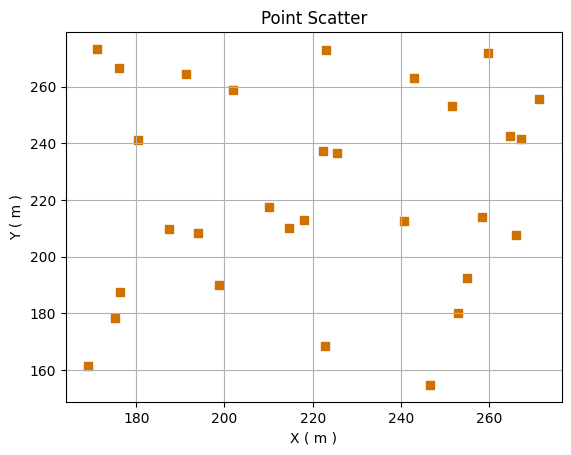

In [ ]:
# define class
class SRVDTProcess:
    # initial method
    def __init__(self, FilePath):
        self.FilePath = FilePath
        self.id = np.array([])
        self.x = np.array([])
        self.y = np.array([])
        self.z = np.array([])

    # extract method : extracts the data from file using pandas
    def ExtractCoordinates(self):
        Df = pd.read_csv(self.FilePath, sep=',')
        self.id = Df['id'].to_numpy()
        self.x = Df['x'].to_numpy()
        self.y = Df['y'].to_numpy()
        self.z = Df['z'].to_numpy()

        # returns as dictionary
        return {
            'id': self.id,
            'x': self.x,
            'y': self.y,
            'z': self.z
        }
    
    # computation method : calculates average , median , and standard deviation
    def ComputeStats(self):
        Avg = np.mean(self.z)
        Median = np.median(self.z)
        Std = np.std(self.z)
        
        # returns as dictionary
        return {
            'Avg' : Avg,
            'Median' : Median,
            'Std' : Std
        }

    # display method : displays the calculated variables
    def StaDisplay(self):
        Stats = self.ComputeStats()
        print(f"Average Z: {Stats['Avg']:.3f}")
        print(f"Median Z: {Stats['Median']:.3f}")
        print(f"Std Z: {Stats['Std']:.3f}")

    # outlier method : finds points with the distance +2std from the mean and saves as csv file
    def FindOutlier(self):
        Stats = self.ComputeStats()
        Avg = Stats['Avg']
        Std = Stats['Std']
        Mask = (self.z > Avg + (2 * Std)) | (self.z < Avg - (2 * Std))
        OutlierData = np.column_stack((self.id[Mask], self.x[Mask], self.y[Mask], self.z[Mask]))

        # save as csv
        np.savetxt(
            'Outliers.csv' ,
            OutlierData ,
            delimiter = '\t' ,
            header = 'id\tx\ty\tz' ,
            comments = '' ,
            fmt = '%s'
        )

        # report save success
        print(f"Found {len(OutlierData)} Outlier(s). Saved to Outliers.csv")
        return OutlierData

    # plot method : displays the scatter plot using matplotlib as picturte.
    def PtShow(self):
        plt.scatter(self.x, self.y, color=(207/255, 114/255, 0/255), marker='s')
        plt.xlabel('X ( m )')
        plt.ylabel('Y ( m )')
        plt.title('Point Scatter')
        plt.grid(True)
        plt.show()

# sample
# MyFile = SRVDTProcess(r"C:/users/<YourUserName>/Desktop/TheFile.csv")
MyFile = SRVDTProcess("TheFile.csv")
MyFile.ExtractCoordinates()
MyFile.StaDisplay()
MyFile.FindOutlier()
MyFile.PtShow()